# STFT vs STFT-SST Deep Dive

Explores the Short-Time Fourier Transform and its Synchrosqueezed variant.

Topics:
1. STFT spectrogram basics — window choice and overlap
2. Window effect comparison (Hann vs Blackman vs rectangular)
3. STFT vs STFT-SST concentration (Gini coefficient)
4. Ridge extraction from STFT-SST
5. STFT-SST reconstruction vs original signal

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import wavesst
from wavesst.viz.tf_plot import _to_numpy
from wavesst.viz.interactive import iplot_stft, iplot_stft_sst, iplot_ridges, iplot_components

%matplotlib inline
print(f'wavesst {wavesst.__version__}')

wavesst 0.1.0


## 1 — Signal

Two crossing chirps at fs = 512 Hz.

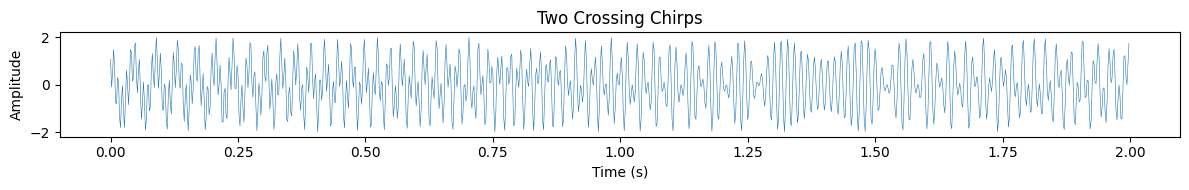

In [3]:
FS = 512.0
T  = 2.0
t  = np.arange(int(T * FS)) / FS
N  = len(t)
cfg = wavesst.Config(device='cpu', dtype='complex64')

f_lin  = 20 + 80 * t / T
f_quad = 120 - 90 * (t / T) ** 2
x = (np.cos(2*np.pi*np.cumsum(f_lin)/FS)
   + np.cos(2*np.pi*np.cumsum(f_quad)/FS)).astype(np.float32)

fig, ax = plt.subplots(figsize=(12, 2))
ax.plot(t, x, lw=0.4)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title('Two Crossing Chirps')
plt.tight_layout()
plt.show()

## 2 — Window Effect

Compare Hann vs Hamming windows and two overlap settings on the STFT.
More overlap = smoother time axis; window shape affects sidelobe leakage.

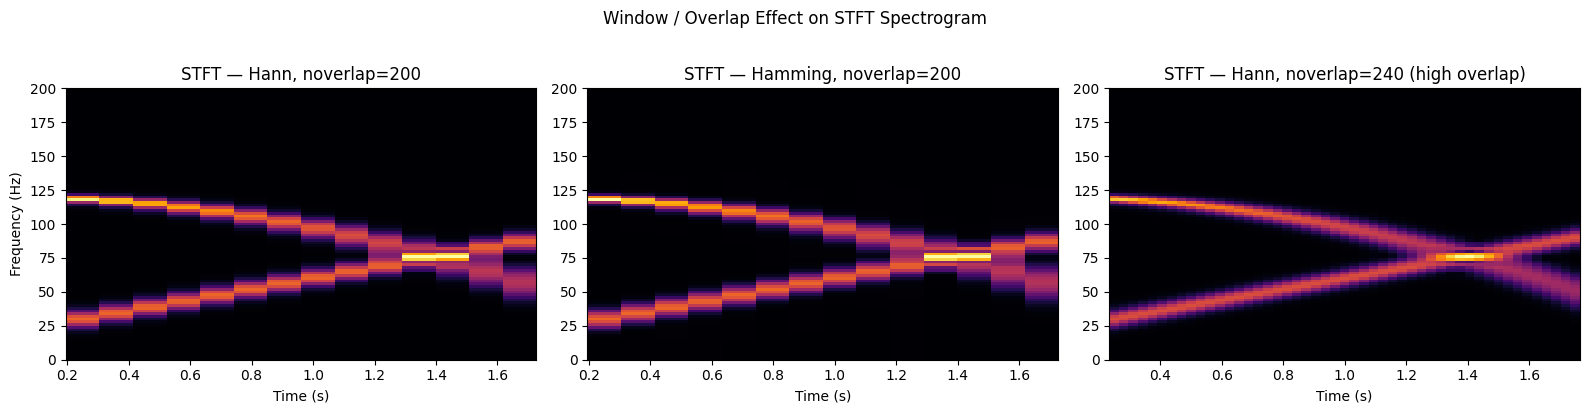

In [4]:
configs = [
    ('hann',    200, 'Hann, noverlap=200'),
    ('hamming', 200, 'Hamming, noverlap=200'),
    ('hann',    240, 'Hann, noverlap=240 (high overlap)'),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (wname, noverlap, title) in zip(axes, configs):
    r = wavesst.stft(x, fs=FS, nperseg=256, noverlap=noverlap, window=wname, cfg=cfg)
    V_mag = _to_numpy(r.V.abs())
    ax.pcolormesh(_to_numpy(r.times), _to_numpy(r.freqs), V_mag,
                  shading='auto', cmap='inferno')
    ax.set_ylim(0, 200)
    ax.set_title(f'STFT — {title}')
    ax.set_xlabel('Time (s)')
    if ax is axes[0]:
        ax.set_ylabel('Frequency (Hz)')

plt.suptitle('Window / Overlap Effect on STFT Spectrogram', y=1.02)
plt.tight_layout()
plt.show()

## 3 — STFT vs STFT-SST Concentration

Gini coefficient of the energy marginal: higher = more concentrated.

STFT     Gini: 0.7042
STFT-SST Gini: 0.7065  (higher = more concentrated)


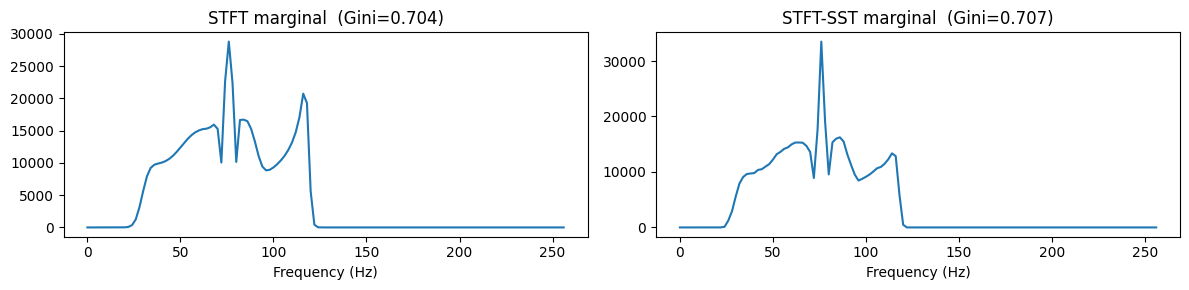

In [5]:
def gini(e):
    e = np.sort(np.abs(e))
    n = len(e)
    return (2 * np.sum(np.arange(1, n+1) * e) / (n * e.sum()) - (n+1)/n)

stft_r     = wavesst.stft(x, fs=FS, nperseg=256, noverlap=240, cfg=cfg)
stft_sst_r = wavesst.stft_sst(x, fs=FS, nperseg=256, noverlap=240, gamma='auto', cfg=cfg)

stft_energy     = _to_numpy(stft_r.V.abs().pow(2).sum(dim=1))
stft_sst_energy = _to_numpy(stft_sst_r.Tx.abs().pow(2).sum(dim=1))

print(f'STFT     Gini: {gini(stft_energy):.4f}')
print(f'STFT-SST Gini: {gini(stft_sst_energy):.4f}  (higher = more concentrated)')

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(_to_numpy(stft_r.freqs), stft_energy)
axes[0].set_title(f'STFT marginal  (Gini={gini(stft_energy):.3f})')
axes[0].set_xlabel('Frequency (Hz)')
axes[1].plot(_to_numpy(stft_sst_r.freqs), stft_sst_energy)
axes[1].set_title(f'STFT-SST marginal  (Gini={gini(stft_sst_energy):.3f})')
axes[1].set_xlabel('Frequency (Hz)')
plt.tight_layout()
plt.show()

## 4 — Interactive Plots

In [6]:
print('--- Interactive STFT ---')
iplot_stft(stft_r)

--- Interactive STFT ---


Output()

In [7]:
print('--- Interactive STFT-SST ---')
iplot_stft_sst(stft_sst_r)

--- Interactive STFT-SST ---


Output()

## 5 — Ridge Extraction and Reconstruction

In [8]:
ridges = wavesst.extract_ridges(stft_sst_r, n=2, penalty=2.0)
for i, r in enumerate(ridges):
    print(f'Ridge {i+1}: median = {np.median(r.freq_path):.1f} Hz,  energy = {r.energy:.2e}')
iplot_ridges(stft_sst_r, ridges)

Ridge 1: median = 98.0 Hz,  energy = 2.15e+03
Ridge 2: median = 60.0 Hz,  energy = 1.97e+03


Output()

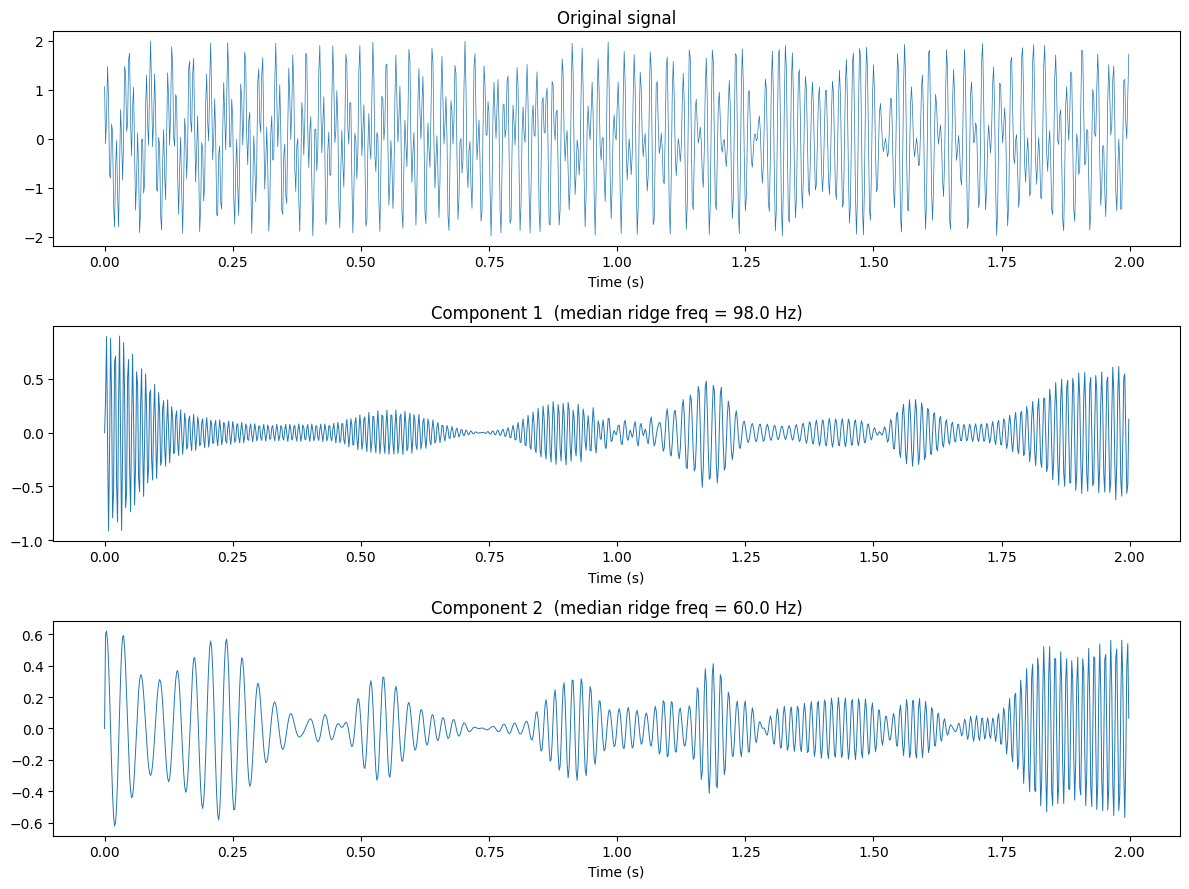

Output()

In [9]:
comps = wavesst.reconstruct(stft_sst_r, ridges, fs=FS)

fig, axes = plt.subplots(len(comps) + 1, 1, figsize=(12, 3*(len(comps)+1)))
axes[0].plot(t, x, lw=0.5, label='Original')
axes[0].set_title('Original signal')
axes[0].set_xlabel('Time (s)')

for i, c in enumerate(comps):
    sample_times = np.arange(len(c.signal)) / FS
    axes[i+1].plot(sample_times, c.signal, lw=0.7, label=f'Component {i+1}')
    axes[i+1].set_title(f'Component {i+1}  (median ridge freq = {np.median(ridges[i].freq_path):.1f} Hz)')
    axes[i+1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

iplot_components(comps, t)